# Supervised – PneumoniaMNIST: model comparison & evaluation

This notebook implements the **training / evaluation** part of CVRIE supervised learning:

- **Pre-processing** (from notebook 01): flatten 28×28 → 784, cast to float, divide by **255**.
- **Several algorithms** under the subject tool constraint (**scikit-learn** only).
- **Metrics**: **log loss**, **Brier score**, **balanced accuracy**, **MCC**, **precision / recall / F1**, **specificity / NPV** (normal), **confusion matrix**, **calibration** plots.
- **Splits**: fit on `train`, select/compare on `val`, **final** generalisation estimate on `test` (after choosing the model on `val`).

**Compliance**: only `train_images` / `train_labels` (and val/test for evaluation) are used—no hidden metadata columns.

## 0) Loss functions: what we optimise vs what we report

- **Logistic regression** (multinomial / binary) minimises **logistic loss** (binary log loss / cross-entropy), which penalises confident mistakes; this aligns with calibrated probabilities and with reporting **log loss** on hold-out data.
- **Random forest** greedily reduces **Gini impurity** (or entropy) in each split—not the same number as log loss, but we can still compute **predict_proba** and evaluate **log loss** for comparison.
- **Linear SVM** (`LinearSVC`) minimises **hinge loss** (margin objective); by default it does not return probabilities. We wrap it with **`CalibratedClassifierCV`** Platt-style scaling so we obtain **`predict_proba`** and comparable **log loss**.

For an **imbalanced** dataset, accuracy alone is misleading; we keep **balanced class weights** where supported and track **precision/recall/F1** per class.

In [6]:
from __future__ import annotations

import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _d in (_cwd, _cwd / "supervised"):
    if (_d / "pneumonia_preprocessing.py").is_file() and str(_d) not in sys.path:
        sys.path.insert(0, str(_d))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    matthews_corrcoef,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from pneumonia_evaluation import (
    confusion_rates,
    predict_from_threshold,
    tune_threshold_balanced_accuracy,
)
from pneumonia_preprocessing import build_preprocess

plt.style.use("seaborn-v0_8")

_cwd_r = Path.cwd().resolve()
DATA_DIR = next(
    (p for p in (_cwd_r / "pneumoniamnist", _cwd_r.parent / "pneumoniamnist") if p.is_dir()),
    _cwd_r.parent / "pneumoniamnist",
)
FIG_DIR = DATA_DIR.parent / "supervised" / "figures"
ARTIFACTS = DATA_DIR.parent / "supervised" / "artifacts"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = ["normal", "pneumonia"]
RANDOM_STATE = 42


def save_current_fig(filename: str) -> None:
    path = FIG_DIR / filename
    plt.gcf().savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")


def load_split(name: str) -> tuple[np.ndarray, np.ndarray]:
    X = np.load(DATA_DIR / f"{name}_images.npy")
    y = np.load(DATA_DIR / f"{name}_labels.npy").astype(np.int64).ravel()
    return X, y


X_train, y_train = load_split("train")
X_val, y_val = load_split("val")
X_test, y_test = load_split("test")
print("train", X_train.shape, y_train.shape)
print("val  ", X_val.shape, y_val.shape)
print("test ", X_test.shape, y_test.shape)

train (4708, 28, 28) (4708,)
val   (524, 28, 28) (524,)
test  (624, 28, 28) (624,)


## 1) Pre-processing

Pipeline step: **reshape + divide by 255** (see notebook 01). No `StandardScaler`: features are already on a bounded \[0,1\] scale.

In [7]:
pre = build_preprocess()

models: dict[str, Pipeline] = {
    "logistic_regression": Pipeline(
        [
            ("prep", pre),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "random_forest": Pipeline(
        [
            ("prep", pre),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "linear_svc_calibrated": Pipeline(
        [
            ("prep", pre),
            (
                "clf",
                CalibratedClassifierCV(
                    LinearSVC(class_weight="balanced", dual=False, random_state=RANDOM_STATE),
                    cv=3,
                ),
            ),
        ]
    ),
}

list(models.keys())

['logistic_regression', 'random_forest', 'linear_svc_calibrated']

## 2) Train on `train`, compare on `val`

Each estimator is **fit only on the training split**. We report **log loss**, **Brier score**, and **balanced accuracy** at the default 0.5 probability cut-off, then **tune a single threshold** on `val` (grid on P(pneumonia)) to **maximise balanced accuracy**, which reduces lopsided **false positives on “normal”** that `class_weight='balanced'` can otherwise create.

**Final model choice**: highest **validation balanced accuracy after threshold tuning**; **log loss** is the first tie-break (better calibration among equally balanced models).

In [8]:
rows = []
fitted: dict[str, Pipeline] = {}
thresholds: dict[str, float] = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    proba = pipe.predict_proba(X_val)
    p_pneu = proba[:, 1]
    pred_def = pipe.predict(X_val)
    ll = log_loss(y_val, proba)
    brier = brier_score_loss(y_val, p_pneu)
    bal_def = balanced_accuracy_score(y_val, pred_def)
    t_star, bal_tuned = tune_threshold_balanced_accuracy(y_val, p_pneu)
    thresholds[name] = t_star
    pred_tuned = predict_from_threshold(proba, t_star)
    m = confusion_rates(y_val, pred_tuned)
    rows.append(
        {
            "model": name,
            "val_log_loss": ll,
            "val_brier": brier,
            "val_bal_acc_default": bal_def,
            "val_bal_acc_tuned": bal_tuned,
            "threshold_P_pneumo_ge": t_star,
            "val_specificity_normal": m["specificity_normal"],
            "val_npv_normal": m["npv_normal"],
            "val_sensitivity_pneumonia": m["sensitivity_pneumonia"],
        }
    )

leader = (
    pd.DataFrame(rows)
    .sort_values(["val_bal_acc_tuned", "val_log_loss"], ascending=[False, True])
    .reset_index(drop=True)
)
display(leader)

best_name = str(leader.loc[0, "model"])
print("Selected: max val balanced accuracy after threshold tune; tie-break lower log loss:", best_name)
print("Thresholds P(pneumonia) >= t:", thresholds)

,model,val_log_loss,val_brier,val_bal_acc_default,val_bal_acc_tuned,threshold_P_pneumo_ge,val_specificity_normal,val_npv_normal,val_sensitivity_pneumonia
0,logistic_regression,0.127167,0.036826,0.953356,0.955470,0.59,0.977778,0.835443,0.933162
1,linear_svc_calibrated,0.114473,0.032858,0.929173,0.952223,0.65,0.948148,0.882759,0.956298
2,random_forest,0.149787,0.040736,0.933181,0.935971,0.69,0.925926,0.856164,0.946015


Selected: max val balanced accuracy after threshold tune; tie-break lower log loss: logistic_regression
Thresholds P(pneumonia) >= t: {'logistic_regression': 0.59, 'random_forest': 0.6900000000000001, 'linear_svc_calibrated': 0.65}


Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/supervised_val_confusion_matrices.png


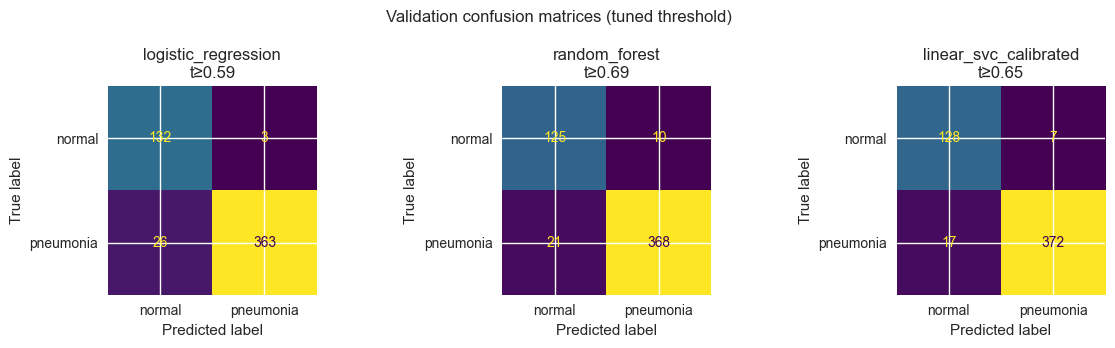

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, name in zip(axes, fitted.keys()):
    proba_v = fitted[name].predict_proba(X_val)
    pred = predict_from_threshold(proba_v, thresholds[name])
    ConfusionMatrixDisplay.from_predictions(
        y_val, pred, display_labels=LABEL_NAMES, ax=ax, colorbar=False
    )
    ax.set_title(f"{name}\nt≥{thresholds[name]:.2f}")
plt.suptitle("Validation confusion matrices (tuned threshold)")
plt.tight_layout()
save_current_fig("supervised_val_confusion_matrices.png")
plt.show()

Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/supervised_calibration_val.png


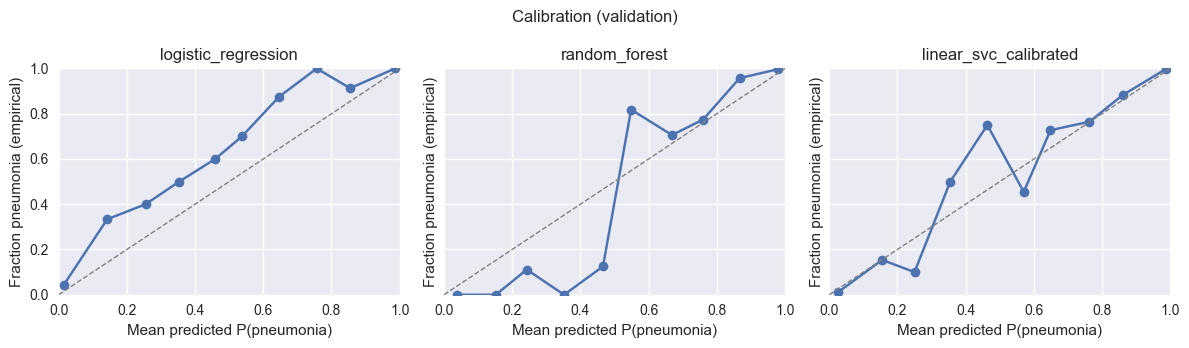

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, name in zip(axes, fitted.keys()):
    p_p = fitted[name].predict_proba(X_val)[:, 1]
    prob_true, prob_pred = calibration_curve(
        y_val, p_p, n_bins=10, strategy="uniform"
    )
    ax.plot(prob_pred, prob_true, marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("Mean predicted P(pneumonia)")
    ax.set_ylabel("Fraction pneumonia (empirical)")
    ax.set_title(name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.suptitle("Calibration (validation)")
plt.tight_layout()
save_current_fig("supervised_calibration_val.png")
plt.show()

## 3) Final fit (`train` + `val`) and **test** evaluation

After model and **threshold** selection on `val` (threshold tuned on `val` using models fit on `train` **only**—no test leakage), we **refit** each architecture on `train` ∪ `val`, apply the **same** validation-chosen threshold, and compare **all** candidates on **`test`**.

The **final** saved artifact uses the single **best** model row from section 2.

,model,test_log_loss,test_brier,test_balanced_accuracy,test_mcc,specificity_normal,npv_normal,sensitivity_pneumonia,precision_pneumonia
1,random_forest,0.418650,0.118239,0.854701,0.723492,0.786325,0.859813,0.923077,0.878049
0,logistic_regression,0.459593,0.102971,0.849145,0.744964,0.726496,0.939227,0.971795,0.855530
2,linear_svc_calibrated,0.503730,0.119624,0.847436,0.746285,0.717949,0.949153,0.976923,0.852349


Final model: logistic_regression  threshold P(pneumo) >= 0.5900  test log loss: 0.45959
              precision    recall  f1-score   support

      normal     0.9392    0.7265    0.8193       234
   pneumonia     0.8555    0.9718    0.9100       390

    accuracy                         0.8798       624
   macro avg     0.8974    0.8491    0.8646       624
weighted avg     0.8869    0.8798    0.8760       624

Clinical rates (test): {'TN': 170, 'FP': 64, 'FN': 11, 'TP': 379, 'specificity_normal': 0.7264957264957265, 'npv_normal': 0.9392265193370166, 'sensitivity_pneumonia': 0.9717948717948718, 'precision_pneumonia': 0.8555304740406321}
Saved: /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/figures/supervised_test_confusion_and_calibration.png


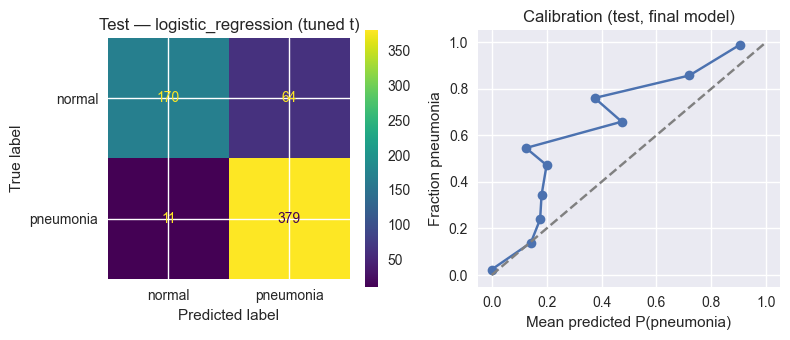

Wrote /Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/supervised/artifacts/best_pipeline.joblib


In [11]:
X_tv = np.concatenate([X_train, X_val], axis=0)
y_tv = np.concatenate([y_train, y_val], axis=0)

test_rows = []
refit_pipes: dict[str, Pipeline] = {}
for name in fitted:
    pipe = clone(fitted[name])
    pipe.fit(X_tv, y_tv)
    refit_pipes[name] = pipe
    proba_te = pipe.predict_proba(X_test)
    t = thresholds[name]
    pred_te_m = predict_from_threshold(proba_te, t)
    ll_te = log_loss(y_test, proba_te)
    br_te = brier_score_loss(y_test, proba_te[:, 1])
    m = confusion_rates(y_test, pred_te_m)
    test_rows.append(
        {
            "model": name,
            "test_log_loss": ll_te,
            "test_brier": br_te,
            "test_balanced_accuracy": balanced_accuracy_score(y_test, pred_te_m),
            "test_mcc": matthews_corrcoef(y_test, pred_te_m),
            "specificity_normal": m["specificity_normal"],
            "npv_normal": m["npv_normal"],
            "sensitivity_pneumonia": m["sensitivity_pneumonia"],
            "precision_pneumonia": m["precision_pneumonia"],
        }
    )

test_leader = pd.DataFrame(test_rows).sort_values(
    "test_balanced_accuracy", ascending=False
)
display(test_leader)

final_pipe = refit_pipes[best_name]
t_final = thresholds[best_name]
proba_te = final_pipe.predict_proba(X_test)
pred_te = predict_from_threshold(proba_te, t_final)
ll_te = log_loss(y_test, proba_te)
print(
    f"Final model: {best_name}  threshold P(pneumo) >= {t_final:.4f}  test log loss: {ll_te:.5f}"
)
print(classification_report(y_test, pred_te, target_names=LABEL_NAMES, digits=4))
print("Clinical rates (test):", confusion_rates(y_test, pred_te))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_te, display_labels=LABEL_NAMES, ax=axes[0]
)
axes[0].set_title(f"Test — {best_name} (tuned t)")
p_cal, y_cal = calibration_curve(y_test, proba_te[:, 1], n_bins=10, strategy="uniform")
axes[1].plot(p_cal, y_cal, marker="o")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Mean predicted P(pneumonia)")
axes[1].set_ylabel("Fraction pneumonia")
axes[1].set_title("Calibration (test, final model)")
plt.tight_layout()
save_current_fig("supervised_test_confusion_and_calibration.png")
plt.show()

artifact_path = ARTIFACTS / "best_pipeline.joblib"
joblib.dump(
    {
        "model_name": best_name,
        "pipeline": final_pipe,
        "labels": LABEL_NAMES,
        "pneumonia_probability_threshold": t_final,
    },
    artifact_path,
)
print("Wrote", artifact_path.resolve())

## 4) Conclusions & defence talking points

- **Why several models?** Linear **logistic regression** is a strong, interpretable baseline on flattened pixels; **random forest** captures non-linear feature interactions without a neural network (tooling constraint); **linear SVM + calibration** explores the margin/hinge objective while still yielding probabilistic outputs for **log loss**.
- **Imbalance**: `class_weight='balanced'` helps rare classes but can **inflate false pneumonia** at a 0.5 cut; we **tune the probability threshold on `val`** (max **balanced accuracy**) and report **specificity / NPV for normal** and **sensitivity for pneumonia**.
- **Calibration**: reliability curves and **Brier score** complement log loss; large val–test gaps deserve a mention in oral defence.
- **Limitations**: 28×28 images discard fine radiological detail; performance is **dataset-specific**, not clinical deployment grade.
- **Deliverable script**: run `train_classify_pneumonia.py` to reproduce training + test predictions as CSV for hand-in.